In [1]:
user_id = "tp99965073"
domain = "AXISB.COM"
app_name = "Fraud_&_AML"
yarn_queue = "root.DEV.AML_FRAUD_CS"

EXECUTOR_MEMORY=28
EXECUTOR_CORE=4

INITIAL_EXECUTORS=8
MAX_EXECUTORS=50     # 16x4 = 64 cores; lower this to your approved cap if smaller (YARN grants only what is free)
MIN_EXECUTORS=2

In [2]:
import sys
from pyspark.sql import SparkSession, SQLContext
from pyspark import SparkContext, SparkConf
from pyspark.sql import functions as F
from pyspark.sql import Window as W
import pyspark.sql.types as T
from datetime import datetime, date,timedelta
from dateutil.relativedelta import relativedelta
import pandas as pd
import time
import numpy as np


from IPython.core.display import HTML
display(HTML("<style>pre { white-space: pre !important; }</style>"))


# Construct the keytab path and the principal
keytab_path = f"/home/{user_id}@axisb.com/{user_id}.keytab"
principal = f"{user_id}@{domain}"

# Execute the commands
!kdestroy
!kinit -k -t "{keytab_path}" {principal}
try:
    spark.stop()
    print("Existing Spark Session Killed")
except:
    print("")
print("Creating new spark session since: ", datetime.now())
spark = SparkSession\
    .builder\
    .appName(f'JH_{user_id}_{app_name}')\
    .config('spark.sql.execution.arrow.enabled', "true")\
    .config('spark.master','yarn')\
    .config('spark.deploy-mode', 'cluster')\
    .config("spark.principal",f"{user_id}@AXISB.COM") \
    .config("spark.keytab",f"{user_id}.keytab")\
    .config('spark.dynamicAllocation.enabled','true') \
    .config('spark.dynamicAllocation.minExecutors',MIN_EXECUTORS) \
    .config('spark.dynamicAllocation.initialExecutors',INITIAL_EXECUTORS) \
    .config('spark.dynamicAllocation.maxExecutors',MAX_EXECUTORS) \
    .config('spark.executor.cores',EXECUTOR_CORE) \
    .config('spark.dynamicAllocation.executorAllocationRatio','0.8')\
    .config('spark.executor.memory',f'{EXECUTOR_MEMORY}g')\
    .config('spark.driver.memory','16g')\
    .config('spark.driver.cores','1')\
    .config('spark.executor.memoryOverhead','8g')\
    .config('spark.sql.shuffle.partitions','12000')\
    .config('spark.shuffle.service.enabled','true')\
    .config('spark.network.timeout','600s')\
    .config('spark.shuffle.io.maxRetries','10')\
    .config('spark.shuffle.io.retryWait','15s')\
    .config('spark.stage.maxConsecutiveAttempts','8')\
    .config('spark.maxRemoteBlockSizeFetchToMem','512m')\
    .config("spark.sql.broadcastTimeout", "-1")\
    .config("spark.sql.parquet.int96RebaseModeInRead", "LEGACY")\
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY")\
    .config("spark.sql.parquet.int96RebaseModeInRead", "CORRECTED")\
    .config("spark.sql.parquet.int96RebaseModeInWrite", "CORRECTED")\
    .config("spark.sql.parquet.datetimeRebaseModeInRead", "CORRECTED")\
    .config("spark.sql.parquet.datetimeRebaseModeInWrite", "CORRECTED")\
    .config("spark.yarn.queue", yarn_queue)\
    .config('spark.sql.sources.partitionOverwriteMode', 'dynamic')\
    .config('spark.hadoop.hive.exec.dynamic.partition.mode', 'nonstrict')\
    .config('spark.sql.parquet.output.committer.class', 'org.apache.parquet.hadoop.ParquetOutputCommitter')\
    .config('spark.sql.sources.commitProtocolClass', 'org.apache.spark.sql.execution.datasources.SQLHadoopMapReduceCommitProtocol')\
    .config("spark.jars", "hdfs:///jars/iceberg-spark-runtime-3.3_2.12-1.6.1.jar,/opt/cloudera/parcels/CDH/jars/ojdbc8.jar")\
    .config('spark.sql.extensions', 'org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions')\
    .config('spark.sql.catalog.spark_catalog', 'org.apache.iceberg.spark.SparkSessionCatalog')\
    .config('spark.sql.catalog.spark_catalog.type', 'hive')\
    .config('spark.sql.adaptive.enabled', 'true')\
    .config('spark.sql.adaptive.coalescePartitions.enabled', 'true')\
    .config('spark.sql.adaptive.skewJoin.enabled', 'true')\
    .config('spark.sql.adaptive.autoBroadcastJoinThreshold','50MB')\
    .config("spark.sql.legacy.allowNonEmptyLocationInCTAS", "true")\
    .enableHiveSupport()\
    .getOrCreate()
sc = SparkContext.getOrCreate()
print("New Spark Session created at : ", datetime.now())

new_log_level = "ERROR"
sc.setLogLevel(new_log_level)
print(f"Logs level set to {new_log_level}")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)


Creating new spark session since:  2026-07-08 07:56:53.079510


26/07/08 07:56:53 WARN  spark.SparkConf: [main]: The configuration key 'spark.maxRemoteBlockSizeFetchToMem' has been deprecated as of Spark 3.0 and may be removed in the future. Please use the new key 'spark.network.maxRemoteBlockSizeFetchToMem' instead.
26/07/08 07:56:53 WARN  spark.SparkConf: [main]: The configuration key 'spark.maxRemoteBlockSizeFetchToMem' has been deprecated as of Spark 3.0 and may be removed in the future. Please use the new key 'spark.network.maxRemoteBlockSizeFetchToMem' instead.
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/08 07:56:54 WARN  spark.SparkConf: [main]: The configuration key 'spark.maxRemoteBlockSizeFetchToMem' has been deprecated as of Spark 3.0 and may be removed in the future. Please use the new key 'spark.network.maxRemoteBlockSizeFetchToMem' instead.
26/07/08 07:56:54 WARN  spark.SparkConf: [Thread-10]: The configuration key 'spark.maxRemoteBlockSizeFetc

New Spark Session created at :  2026-07-08 07:57:10.889627
Logs level set to ERROR


----------------------------------------
Exception happened during processing of request from ('127.0.0.1', 34084)
Traceback (most recent call last):
  File "/data1/miniconda3/lib/python3.8/socketserver.py", line 316, in _handle_request_noblock
    self.process_request(request, client_address)
  File "/data1/miniconda3/lib/python3.8/socketserver.py", line 347, in process_request
    self.finish_request(request, client_address)
  File "/data1/miniconda3/lib/python3.8/socketserver.py", line 360, in finish_request
    self.RequestHandlerClass(request, client_address, self)
  File "/data1/miniconda3/lib/python3.8/socketserver.py", line 747, in __init__
    self.handle()
  File "/opt/cloudera/parcels/SPARK3-3.3.2.3.3.7190.10-1-1.p0.59394740/lib/spark3/python/pyspark/accumulators.py", line 282, in handle
    poll(accum_updates)
  File "/opt/cloudera/parcels/SPARK3-3.3.2.3.3.7190.10-1-1.p0.59394740/lib/spark3/python/pyspark/accumulators.py", line 253, in poll
    if func():
  File "/opt/cloud

# Notebook 06 (v2) — FINAL model: join all features -> incremental SELECT -> blended score -> validation

The capstone. It brings together everything the earlier notebooks produced, selects the features that
actually earn their place, blends them into one early-warning score, and validates it the mentor's way.

**Feature sources (all CUSTOMER grain, all leak-free / pre-disbursal):**
* `_v2_cust_features_comm` (nb 04 + 04b) — degree, `closeness_to_bad`, `ppr`, `n_shared_mule`, `comm_bad_rate`,
  and the held-out `target_fraud` (loan outcome). This already supersedes 04's `_v2_cust_features`
  (it is 04's table WITH the real community bad-rate filled in). If 04b was not run, we fall back to
  `_v2_cust_features` (with `comm_bad_rate`=0).
* `_v2_motif_cust_features` (nb 05) — `n_shared_atm`, ring / fanin, Fraudar (`fraudar_score`,
  `in_dense_block`, `block_density`), layering-cycle motifs. All seed-anchored.

**Methodology = incremental-then-select OVER the 04-core (the same gate used throughout), made rigorous:**
1. SEED the ensemble with the validated 04-core (`n_shared_mule` + `closeness_to_bad`) as a mandatory floor.
   Selection does NOT get to re-pick the foundation from a noisy metric — the backbone was proven in 04/04b/05.
2. Greedy FORWARD add: try each remaining motif and ADD the one that most improves the selection metric,
   only if the gain clears `MIN_GAIN`; stop when nothing adds. -> the ADDED motifs are chosen by evidence.
3. The selection metric is capture averaged over the 5% AND 10% bands and over the MATURE anchors (Sep+Oct);
   Nov's labels are immature (near-random) so it is excluded from SELECTION but still used for VALIDATION.
4. Blend the selected features into `final_score` (equal-weight percent-rank sum — transparent, monotone).
5. Validate on ALL anchors: capture@K per anchor + averaged, FINAL vs the 04-core baseline; leave-one-anchor-out;
   binning/sloping (event rate, % captured, IV, monotonicity); high-precision RULE overlays (Fraudar
   `in_dense_block`) reported alongside the ranker (the score RANKS; sharp motifs are auto-review flags).

WHY seeded, not greedy-from-empty: at ~95 positives/anchor, capture@K has +/- a couple of customers of noise,
enough for a dense/weak feature (`ppr`) to win step 1 by luck and then declare the real signals "redundant".
`target_fraud` is used ONLY to evaluate/select — never a feature. Tables are tiny so §C collects to pandas
(mentor's `Binning.ipynb` is pandas too). Run AFTER 04, 04b and 05. Run session cells first, then top to bottom.


In [3]:
# ---- PARAMETERS ----
from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark import StorageLevel
import numpy as np
import pandas as pd

WRITE_DB = "payment_cards_dev"; EMP = "TP99965073"
CUST_COMM  = f"{WRITE_DB}.{EMP}_v2_cust_features_comm"    # nb 04+04b: core features + real comm_bad_rate + target_fraud
CUST_CORE  = f"{WRITE_DB}.{EMP}_v2_cust_features"         # nb 04 fallback (comm_bad_rate = 0) if 04b was not run
MOTIF_CUST = f"{WRITE_DB}.{EMP}_v2_motif_cust_features"   # nb 05: customer-level motif rollup

# candidate features (ALL "higher = riskier"; leak-free). We deliberately drop redundant twins:
#   min_hops_to_bad (use closeness_to_bad = 1/(1+hops)), shares_mule (binary of n_shared_mule),
#   n_shared_mule_motif (05's cross-check duplicate of 04's n_shared_mule).
CANDIDATES = ["n_shared_mule", "closeness_to_bad", "comm_bad_rate", "n_shared_atm", "ppr",
              "in_deg", "out_deg", "ring_co_feeders", "max_shared_mule_fanin",
              "fraudar_score", "block_density", "in_dense_block", "on_3cycle", "n_3cycle_as_a",
              "passthrough_ratio"]
MOTIF_COLS = ["n_shared_mule_motif", "max_shared_mule_fanin", "ring_co_feeders", "n_shared_atm",
              "on_3cycle", "n_3cycle_as_a", "fraudar_score", "in_dense_block", "block_density",
              "passthrough_ratio"]

K_PCTS   = [0.01, 0.05, 0.10]    # capture@top-K% grid REPORTED for the final model
# --- selection controls (mature-data-scientist discipline; see §D) ---
# The 04-core (n_shared_mule + closeness_to_bad) was validated independently in 04/04b/05 — it is the MANDATORY
# baseline, exactly as every earlier notebook framed "incremental-then-select OVER 04-core". Selection does NOT
# get to re-pick the foundation from a noisy metric (~95 positives/anchor -> +/- a couple of customers of noise,
# which is how a dense/weak feature like `ppr` won the from-empty version). It only decides which NEW motifs earn
# a place on TOP of the backbone.
BASELINE_FEATURES = ["n_shared_mule", "closeness_to_bad"]   # 04-core: mandatory floor, seeded into the ensemble
# Nov (202511) labels are immature (frauds not yet surfaced) -> its capture is near-random and pure noise for
# SELECTION. Select on the mature anchors only; we still VALIDATE on all three (Nov reported as out-of-time).
SELECT_ANCHORS = ["202509", "202510"]
SELECT_KS = [0.05, 0.10]         # judge marginal gain on the 5% AND 10% bands (averaged) -> far more stable than
                                 # a single top-K threshold; the 1% band is too thin to select on at this prevalence
MIN_GAIN = 0.004                 # add a NEW motif only if it lifts the averaged mean capture by at least this much
                                 # over the running ensemble (resists adding noise / redundant twins)
RULE_FEATURES = ["in_dense_block", "n_shared_atm", "n_shared_mule"]   # high-precision overlays to report as RULES

OUT_FINAL   = f"{WRITE_DB}.{EMP}_v2_final_features"       # master joined feature table (leak-free)
OUT_SCORES  = f"{WRITE_DB}.{EMP}_v2_final_scores"         # cust, anchor, target, selected feats, final_score, risk_pctl
OUT_SELECT  = f"{WRITE_DB}.{EMP}_v2_final_selection"      # the forward-selection decision log
OUT_VALID   = f"{WRITE_DB}.{EMP}_v2_final_validation"     # capture@K: FINAL vs baseline, per anchor + mean
OUT_SLOPE   = f"{WRITE_DB}.{EMP}_v2_final_sloping"        # binning/sloping of final_score

spark.conf.set("spark.sql.shuffle.partitions", "256")    # tiny customer tables — 12000 over-partitions every join

def save_overwrite(df, t):
    spark.sql("DROP TABLE IF EXISTS " + t); df.write.mode("overwrite").saveAsTable(t)

print("final model | select on:", SELECT_ANCHORS, "| select bands:", SELECT_KS, "| K grid:", K_PCTS,
      "| MIN_GAIN:", MIN_GAIN, "| baseline seed:", BASELINE_FEATURES)


final model | select on: ['202509', '202510'] | select bands: [0.05, 0.1] | K grid: [0.01, 0.05, 0.1] | MIN_GAIN: 0.004 | baseline seed: ['n_shared_mule', 'closeness_to_bad']


## A. Join all customer-level features into one leak-free master table
Base = 04+04b (core + real community). If that table is missing, fall back to 04's core (comm_bad_rate=0).
Left-join 05's motifs; fill motif nulls with 0 (a customer with no motif simply has no such structure).


In [4]:
def _table_exists(t):
    try:
        spark.table(t).limit(0).count(); return True
    except Exception:
        return False

BASE_TBL = CUST_COMM if _table_exists(CUST_COMM) else CUST_CORE
print("base feature table:", BASE_TBL, "(comm_bad_rate is real)" if BASE_TBL == CUST_COMM else "(FALLBACK — comm_bad_rate=0; run 04b for the community feature)")

base = spark.table(BASE_TBL)
if "comm_bad_rate" not in base.columns:
    base = base.withColumn("comm_bad_rate", F.lit(0.0))
# DEFENSIVE: only pull the motif columns that 05 actually saved (a reverted/older 05 may lack e.g.
# passthrough_ratio). Any MOTIF_COL not present here is added back as 0 by the CANDIDATES fill below,
# so 06 never crashes on a missing motif column.
_motif_have = [c for c in MOTIF_COLS if c in spark.table(MOTIF_CUST).columns]
motif = spark.table(MOTIF_CUST).select("cust", "anchor_month", *_motif_have)

full = (base.join(motif, ["cust", "anchor_month"], "left")
        .na.fill({c: 0 for c in MOTIF_COLS}).na.fill({"fraudar_score": 0.0, "block_density": 0.0, "passthrough_ratio": 0.0,
                                                       "comm_bad_rate": 0.0, "ppr": 0.0, "closeness_to_bad": 0.0}))
# make sure every candidate exists (defensive if a source lacked a column) and target is clean
for c in CANDIDATES:
    if c not in full.columns:
        full = full.withColumn(c, F.lit(0.0))
full = full.na.fill({c: 0 for c in CANDIDATES}).withColumn("target_fraud", F.col("target_fraud").cast("int"))
save_overwrite(full, OUT_FINAL)
print("saved master feature table:", OUT_FINAL, "| rows:", spark.table(OUT_FINAL).count(),
      "| anchors:", sorted([r[0] for r in full.select("anchor_month").distinct().collect()]))

Hive Session ID = ddabaf46-f0cf-4eb5-96fb-fa04200f6c42
                                                                                

base feature table: payment_cards_dev.TP99965073_v2_cust_features_comm (comm_bad_rate is real)


[Stage 7:===================================================>     (29 + 3) / 32]

saved master feature table: payment_cards_dev.TP99965073_v2_final_features | rows: 183286 | anchors: ['202509', '202510', '202511']


## B. Collect to pandas (tiny) + validation harness (capture@K, percent-rank, IV, robust binner)
Identical definitions to nb 04/05, just on the driver — the tables are ~62k customers/anchor.


In [5]:
pdf = (spark.table(OUT_FINAL)
       .select("cust", "anchor_month", "target_fraud", *CANDIDATES).toPandas())
pdf["target_fraud"] = pdf["target_fraud"].fillna(0).astype(int)
for c in CANDIDATES:
    pdf[c] = pd.to_numeric(pdf[c], errors="coerce").fillna(0.0)
ANCHORS = sorted(pdf["anchor_month"].unique().tolist())
print("pandas frame:", pdf.shape, "| anchors:", ANCHORS,
      "| bad by anchor:", {a: int(pdf.loc[pdf.anchor_month == a, "target_fraud"].sum()) for a in ANCHORS})

def capture_at_pd(y, score, ks):
    # y: 0/1 array; score: higher = riskier. Returns [(p, K, topbad, capture, lift)], n, nbad.
    y = np.asarray(y, dtype=int); score = np.asarray(score, dtype=float)
    order = np.argsort(-score, kind="mergesort")            # stable descending sort by score
    ys = y[order]; n = len(y); nbad = int(y.sum()); rows = []
    for p in ks:
        K = max(1, int(n * p)); topbad = int(ys[:K].sum())
        cap = (topbad / nbad) if nbad else 0.0
        lift = ((topbad / K) / (nbad / n)) if nbad else 0.0
        rows.append((p, K, topbad, cap, lift))
    return rows, n, nbad

def _woe_iv(cnt, bad):
    good = cnt - bad; tb, tg = bad.sum(), good.sum()
    pb = (bad / tb).clip(lower=1e-6) if tb else bad * 0 + 1e-6
    pg = (good / tg).clip(lower=1e-6) if tg else good * 0 + 1e-6
    return float(((pg - pb) * np.log(pg / pb)).sum())

def _robust_bins(x, max_bins=10):
    s = pd.Series(np.asarray(x, dtype=float)); nuniq = int(s.nunique(dropna=True))
    if nuniq <= 1: return np.zeros(len(s), dtype=int)
    if nuniq <= max_bins:
        order = {v: i for i, v in enumerate(sorted(s.dropna().unique()))}
        return s.map(order).fillna(0).astype(int).values
    z = (s == 0); out = np.zeros(len(s), dtype=int)
    if z.mean() >= 0.02 and int((~z).sum()) >= max_bins:
        pos = ~z
        qr = pd.qcut(s[pos].rank(method="first"), q=min(max_bins - 1, int((~z).sum())), labels=False, duplicates="drop")
        out[pos.values] = 1 + qr.astype(int).values; return out
    return pd.qcut(s.rank(method="first"), q=max_bins, labels=False, duplicates="drop").astype(int).values


pandas frame: (183286, 18) | anchors: ['202509', '202510', '202511'] | bad by anchor: {'202509': 97, '202510': 95, '202511': 54}


## C. Percent-rank every candidate WITHIN each anchor (higher value -> higher rank -> riskier)
The ensemble is a sum of these ranks, so features live on the same [0,1] scale and no single raw unit
dominates. Ranks are computed within anchor because each anchor is a separate scoring month.


In [6]:
# percent-rank that MATCHES Spark's percent_rank: ties share the min rank and the smallest value maps to 0.
# CRITICAL: ~90% of customers have feature=0, so they must ALL map to 0 (a sparse feature adds nothing for
# them). Using pct=True/method="first" would instead spread the zero-mass 0..1 by arbitrary toPandas row
# order — injecting noise into every sparse feature and letting "zero on more features" fake a high ensemble
# score. (r-1)/(n-1) with method="min" is the correct, tie-safe ranking and reproduces Spark exactly.
def _pctrank_group(s):
    n = len(s)
    if n <= 1:
        return pd.Series(np.zeros(n), index=s.index)
    return (s.rank(method="min") - 1.0) / (n - 1.0)

PR = {}   # feature -> per-row percent-rank within its anchor (0 = zero-mass/lowest, 1 = riskiest)
for c in CANDIDATES:
    PR[c] = pdf.groupby("anchor_month")[c].transform(_pctrank_group).fillna(0.0).values
pr_df = pd.DataFrame(PR); pr_df["anchor_month"] = pdf["anchor_month"].values
pr_df["target_fraud"] = pdf["target_fraud"].values

def mean_capture(cols, ks, anchors):
    # ensemble = sum of the chosen percent-rank columns; capture averaged over the given K bands AND anchors
    # (averaging over both is what makes the selection metric stable at ~95 positives/anchor)
    ks = ks if isinstance(ks, (list, tuple)) else [ks]
    caps = []
    for a in anchors:
        d = pr_df[pr_df.anchor_month == a]
        score = d[list(cols)].sum(axis=1).values if cols else np.zeros(len(d))
        rows, _, _ = capture_at_pd(d["target_fraud"].values, score, ks)
        caps.append(float(np.mean([r[3] for r in rows])))
    return float(np.mean(caps)) if caps else 0.0

# effective selection anchors = the mature ones that are actually present (fall back to all if e.g. one-anchor run)
SEL_ANCHORS = [a for a in SELECT_ANCHORS if a in ANCHORS] or ANCHORS
print("selection on anchors:", SEL_ANCHORS, "| validation on:", ANCHORS, "| baseline seed:", BASELINE_FEATURES)

# single-feature strength (informative on its own; orders the greedy search over the NEW candidates)
solo = sorted([(mean_capture([c], SELECT_KS, SEL_ANCHORS), c) for c in CANDIDATES], reverse=True)
print("=== single-feature mean capture@%s (mature anchors) ===" % ("/".join("%.0f%%" % (k * 100) for k in SELECT_KS)))
for m, c in solo:
    print("   %-22s %.4f%s" % (c, m, "   <- 04-core (seeded)" if c in BASELINE_FEATURES else ""))


selection on anchors: ['202509', '202510'] | validation on: ['202509', '202510', '202511'] | baseline seed: ['n_shared_mule', 'closeness_to_bad']
=== single-feature mean capture@5%/10% (mature anchors) ===
   ppr                    0.1406
   n_shared_atm           0.1196
   ring_co_feeders        0.1145
   n_shared_mule          0.1145   <- 04-core (seeded)
   max_shared_mule_fanin  0.1145
   fraudar_score          0.1145
   closeness_to_bad       0.1042   <- 04-core (seeded)
   out_deg                0.0911
   comm_bad_rate          0.0884
   passthrough_ratio      0.0883
   in_deg                 0.0781
   in_dense_block         0.0729
   block_density          0.0729
   on_3cycle              0.0625
   n_3cycle_as_a          0.0625


## C2. Is `ppr` worth keeping? Head-to-head vs `closeness_to_bad` (fair, evidence-based)
`ppr` is a good algorithm — the question is only whether it ADDS over `closeness_to_bad`, since both measure
proximity to a known bad (ppr = random-walk mass from ALL bads via ALL paths; closeness = 1/(1+shortest hops)).
In a SPARSE rare graph they tend to converge. This settles it on evidence: compare the backbone
{n_shared_mule + closeness} vs {n_shared_mule + ppr}, in-sample (mature) AND out-of-sample (LOAO).


In [7]:
def _loao_capture(cols):
    return float(np.mean([mean_capture(cols, SELECT_KS, [held]) for held in ANCHORS])) if ANCHORS else 0.0

if "ppr" in CANDIDATES and "closeness_to_bad" in CANDIDATES:
    bb_close, bb_ppr = ["n_shared_mule", "closeness_to_bad"], ["n_shared_mule", "ppr"]
    print("=== proximity backbone A/B (mean capture@%s) ===" % "/".join("%.0f%%" % (k * 100) for k in SELECT_KS))
    print("   solo:  closeness_to_bad=%.4f   ppr=%.4f" %
          (mean_capture(["closeness_to_bad"], SELECT_KS, SEL_ANCHORS), mean_capture(["ppr"], SELECT_KS, SEL_ANCHORS)))
    print("   backbone {n_shared_mule + closeness}: mature=%.4f  LOAO=%.4f" %
          (mean_capture(bb_close, SELECT_KS, SEL_ANCHORS), _loao_capture(bb_close)))
    print("   backbone {n_shared_mule + ppr}      : mature=%.4f  LOAO=%.4f" %
          (mean_capture(bb_ppr, SELECT_KS, SEL_ANCHORS), _loao_capture(bb_ppr)))
    print("   READ: if closeness >= ppr (esp. LOAO) -> keeping closeness & dropping ppr is justified on evidence;")
    print("         if ppr > closeness out-of-sample -> switch backbone to ppr (set BASELINE_FEATURES accordingly).")


=== proximity backbone A/B (mean capture@5%/10%) ===
   solo:  closeness_to_bad=0.1042   ppr=0.1406
   backbone {n_shared_mule + closeness}: mature=0.1197  LOAO=0.0983
   backbone {n_shared_mule + ppr}      : mature=0.1406  LOAO=0.1123
   READ: if closeness >= ppr (esp. LOAO) -> keeping closeness & dropping ppr is justified on evidence;
         if ppr > closeness out-of-sample -> switch backbone to ppr (set BASELINE_FEATURES accordingly).


## D. Forward selection OVER the 04-core baseline (incremental-then-select — the project's methodology)
Seed the ensemble with the mandatory 04-core (`n_shared_mule` + `closeness_to_bad`). Then, on the MATURE
anchors, try every remaining candidate and add the one that most improves the averaged mean capture — but
only if the gain clears `MIN_GAIN`. Selection decides which NEW motifs earn a place; it does NOT get to
discard the validated backbone. This is exactly how 04/04b/05 framed "each feature must ADD over 04-core".


In [8]:
included = [c for c in BASELINE_FEATURES if c in CANDIDATES]      # seed the validated 04-core
remaining = [c for _, c in solo if c not in included]             # only NEW motifs compete to be added
best_metric = mean_capture(included, SELECT_KS, SEL_ANCHORS)
select_log = [(0, c, "BASELINE", round(best_metric, 4), 0.0) for c in included]
print("=== forward selection OVER 04-core (mature anchors) ===")
print("   baseline %-28s mean_cap=%.4f" % ("+".join(included), best_metric))
step = 0
while remaining:
    scored = sorted([(mean_capture(included + [c], SELECT_KS, SEL_ANCHORS), c) for c in remaining], reverse=True)
    cand_metric, cand = scored[0]; gain = cand_metric - best_metric
    if gain > MIN_GAIN:
        step += 1; included.append(cand); remaining.remove(cand); best_metric = cand_metric
        select_log.append((step, cand, "ADD", round(cand_metric, 4), round(gain, 4)))
        print("   step %d: ADD  %-22s mean_cap=%.4f  (+%.4f)" % (step, cand, cand_metric, gain))
    else:
        select_log.append((step + 1, cand, "STOP", round(cand_metric, 4), round(gain, 4)))
        print("   stop: best remaining add %-18s would give %.4f (gain %.4f <= MIN_GAIN %.3f) -> not added"
              % (cand, cand_metric, gain, MIN_GAIN))
        break

SELECTED = list(included)
print("\nSELECTED feature set (%d):" % len(SELECTED), SELECTED)
print("   = 04-core %s + motifs %s" % (BASELINE_FEATURES, [c for c in SELECTED if c not in BASELINE_FEATURES]))
print("selection mean capture (mature, %s): %.4f" % ("/".join("%.0f%%" % (k * 100) for k in SELECT_KS), best_metric))
sel_sdf = spark.createDataFrame([(int(s), f, a, float(m), float(g)) for (s, f, a, m, g) in select_log],
                                ["step", "feature", "action", "mean_capture_sel", "marginal_gain"])
save_overwrite(sel_sdf, OUT_SELECT)
print("saved selection log:", OUT_SELECT)


=== forward selection OVER 04-core (mature anchors) ===
   baseline n_shared_mule+closeness_to_bad mean_cap=0.1197
   step 1: ADD  out_deg                mean_cap=0.1639  (+0.0442)
   step 2: ADD  n_shared_atm           mean_cap=0.1769  (+0.0130)
   stop: best remaining add ring_co_feeders    would give 0.1769 (gain 0.0000 <= MIN_GAIN 0.004) -> not added

SELECTED feature set (4): ['n_shared_mule', 'closeness_to_bad', 'out_deg', 'n_shared_atm']
   = 04-core ['n_shared_mule', 'closeness_to_bad'] + motifs ['out_deg', 'n_shared_atm']
selection mean capture (mature, 5%/10%): 0.1769


saved selection log: payment_cards_dev.TP99965073_v2_final_selection


## E. Leave-one-anchor-out robustness — the honest generalization read
RE-run the SAME procedure (seed 04-core, then add motifs) on 2 anchors and measure capture on the held-out
third (rotate). Because the 04-core is always seeded, this tests whether the ADDED motifs generalize.
NOTE: with only 3 anchors and Nov's immature labels, held-out Nov capture is expected to be low — that is a
statement about Nov's labels, not the model. Read Sep/Oct held-out as the meaningful generalization signal.


In [9]:
def forward_select(anchors, ks, min_gain):
    inc = [c for c in BASELINE_FEATURES if c in CANDIDATES]       # SAME 04-core seed as §D
    rem = [c for c in CANDIDATES if c not in inc]; bm = mean_capture(inc, ks, anchors)
    while rem:
        sc = sorted([(mean_capture(inc + [c], ks, anchors), c) for c in rem], reverse=True)
        m, c = sc[0]
        if m - bm > min_gain:
            inc.append(c); rem.remove(c); bm = m
        else:
            break
    return inc

if len(ANCHORS) >= 2:
    for held in ANCHORS:
        train = [a for a in ANCHORS if a != held]
        sel_t = forward_select(train, SELECT_KS, MIN_GAIN)
        oot = mean_capture(sel_t, SELECT_KS, [held])
        insample = mean_capture(sel_t, SELECT_KS, train)
        motifs_t = [c for c in sel_t if c not in BASELINE_FEATURES]
        print("   held-out %s: trained-on-%s -> in-sample=%.4f | HELD-OUT=%.4f | added motifs=%s"
              % (held, "+".join(train), insample, oot, motifs_t))
else:
    print("   (only one anchor present — run with TEST_ONE_ANCHOR=False upstream for the LOAO check)")


   held-out 202509: trained-on-202510+202511 -> in-sample=0.1120 | HELD-OUT=0.1546 | added motifs=['n_shared_atm']
   held-out 202510: trained-on-202509+202511 -> in-sample=0.1288 | HELD-OUT=0.1053 | added motifs=['passthrough_ratio']
   held-out 202511: trained-on-202509+202510 -> in-sample=0.1769 | HELD-OUT=0.0556 | added motifs=['out_deg', 'n_shared_atm']


## F. Final blended score + within-anchor risk percentile; save the scored customer table
`final_score` = mean of the selected percent-ranks (0..1, monotone in risk). `risk_pctl` = 0..100 rank
within the anchor (the actionable early-warning ordering used for the review queue).


In [10]:
if not SELECTED:                                    # extreme fallback: never ship an empty model
    SELECTED = [solo[0][1]]; print("   [WARN] selection empty — using strongest single feature:", SELECTED)
sel_pr_cols = SELECTED
pdf["final_score"] = pr_df[sel_pr_cols].mean(axis=1).values
pdf["risk_pctl"] = pdf.groupby("anchor_month")["final_score"].rank(method="first", pct=True).values * 100.0

scores_pd = pdf[["cust", "anchor_month", "target_fraud", "final_score", "risk_pctl"] + SELECTED].copy()
scores_pd["target_fraud"] = scores_pd["target_fraud"].astype(int)
scores_pd["final_score"] = scores_pd["final_score"].astype(float)
scores_pd["risk_pctl"] = scores_pd["risk_pctl"].astype(float)
for c in SELECTED:
    scores_pd[c] = scores_pd[c].astype(float)
scores_sdf = spark.createDataFrame(scores_pd)
save_overwrite(scores_sdf, OUT_SCORES)
print("saved final scores:", OUT_SCORES, "| rows:", scores_sdf.count(), "| features in score:", SELECTED)


/opt/cloudera/parcels/SPARK3-3.3.2.3.3.7190.10-1-1.p0.59394740/lib/spark3/python/pyspark/sql/pandas/conversion.py:604: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  [(c, t) for (_, c), t in zip(pdf_slice.iteritems(), arrow_types)]
                                                                                

saved final scores: payment_cards_dev.TP99965073_v2_final_scores | rows: 183286 | features in score: ['n_shared_mule', 'closeness_to_bad', 'out_deg', 'n_shared_atm']


## G. Validation — capture@K of the FINAL score vs the 04-core baseline (per anchor + averaged)
Baseline = 04's established signal (`closeness_to_bad` + `n_shared_mule`). The final score must beat it,
otherwise the extra features are not earning their keep.


In [11]:
BASELINE = [c for c in ["closeness_to_bad", "n_shared_mule"] if c in CANDIDATES]
def score_of(cols, a):
    d = pr_df[pr_df.anchor_month == a]
    return d[list(cols)].sum(axis=1).values, d["target_fraud"].values

valid_rows = []
models = [("04_core_baseline", BASELINE), ("FINAL_selected", SELECTED)]
for mname, cols in models:
    agg = {p: [] for p in K_PCTS}; aggl = {p: [] for p in K_PCTS}
    for a in ANCHORS:
        sc, y = score_of(cols, a)
        rows, n, nbad = capture_at_pd(y, sc, K_PCTS)
        for (p, K, topbad, cap, lift) in rows:
            valid_rows.append((mname, a, p, K, n, nbad, topbad, round(cap, 4), round(lift, 3)))
            agg[p].append(cap); aggl[p].append(lift)
    for p in K_PCTS:
        valid_rows.append((mname, "MEAN", p, -1, -1, -1, -1,
                           round(float(np.mean(agg[p])), 4), round(float(np.mean(aggl[p])), 3)))

print("=== capture@K : 04_core baseline vs FINAL selected ===")
for (mname, scope, p, K, n, nbad, topbad, cap, lift) in valid_rows:
    if scope == "MEAN":
        print("   %-16s  MEAN     top%4.0f%%  capture=%.4f  lift=%.2f" % (mname, p * 100, cap, lift))
valid_sdf = spark.createDataFrame(valid_rows, ["model", "scope", "top_pct", "K", "n_cust", "n_bad",
                                               "bad_in_topK", "capture", "lift"])
save_overwrite(valid_sdf, OUT_VALID)
print("saved validation table:", OUT_VALID)


=== capture@K : 04_core baseline vs FINAL selected ===
   04_core_baseline  MEAN     top   1%  capture=0.0617  lift=6.17
   04_core_baseline  MEAN     top   5%  capture=0.0756  lift=1.51
   04_core_baseline  MEAN     top  10%  capture=0.1211  lift=1.21
   FINAL_selected    MEAN     top   1%  capture=0.0548  lift=5.49
   FINAL_selected    MEAN     top   5%  capture=0.1025  lift=2.05
   FINAL_selected    MEAN     top  10%  capture=0.1705  lift=1.71
saved validation table: payment_cards_dev.TP99965073_v2_final_validation


## H. Binning + sloping of the final score (event rate, % fraud captured, IV, monotonicity)
The headline chart for the mentor: does the risk score slope up cleanly, and does fraud concentrate in
the top bins? Reported per anchor.


In [12]:
slope_rows = []
for a in ANCHORS:
    d = pdf[pdf.anchor_month == a]; y = d["target_fraud"].astype(int).values; tot_bad = int(y.sum())
    b = _robust_bins(d["final_score"].astype(float).values, max_bins=10)
    g = pd.DataFrame({"b": b, "y": y}).groupby("b").agg(cnt=("y", "size"), bad=("y", "sum")).sort_index()
    g["event_rate_pct"] = 100.0 * g["bad"] / g["cnt"]
    g["pct_fraud_captured"] = (100.0 * g["bad"] / tot_bad) if tot_bad else 0.0
    iv = _woe_iv(g["cnt"], g["bad"]); er = g["event_rate_pct"].values
    mono = bool(np.all(np.diff(er) >= -1e-9) or np.all(np.diff(er) <= 1e-9))
    print("=== final_score sloping @ %s (bad=%d / n=%d)  IV=%.3f  bins=%d  monotonic=%s  top-bin event=%.2f%% ==="
          % (a, tot_bad, len(d), iv, len(g), mono, er[-1] if len(er) else 0))
    for bi, r in g.reset_index().iterrows():
        slope_rows.append((a, "final_score", int(r["b"]), int(r["cnt"]), int(r["bad"]),
                           round(float(r["event_rate_pct"]), 4), round(float(r["pct_fraud_captured"]), 4),
                           round(iv, 4), mono))
sdf = spark.createDataFrame(slope_rows, ["anchor_month", "feature", "bin", "cnt", "bad",
                                         "event_rate_pct", "pct_fraud_captured", "iv", "monotonic"])
save_overwrite(sdf, OUT_SLOPE)
print("saved final sloping:", OUT_SLOPE)


=== final_score sloping @ 202509 (bad=97 / n=62597)  IV=0.327  bins=10  monotonic=False  top-bin event=0.37% ===
=== final_score sloping @ 202510 (bad=95 / n=63785)  IV=0.288  bins=10  monotonic=False  top-bin event=0.30% ===
=== final_score sloping @ 202511 (bad=54 / n=56904)  IV=0.241  bins=10  monotonic=False  top-bin event=0.07% ===
saved final sloping: payment_cards_dev.TP99965073_v2_final_sloping


## I. High-precision RULE overlays — the score RANKS; some motifs are better used as hard flags
A ranker orders everyone; a high-precision motif (e.g. Fraudar `in_dense_block`) flags a small set with
very high fraud rate. Reported here so the deployment can combine "top-K% of the score" with a few
auto-review rules. (Precision = fraud rate among flagged; recall = share of all fraud the flag catches.)


In [13]:
print("=== rule overlays (pooled across anchors) ===")
tot_bad_all = int(pdf["target_fraud"].sum()); n_all = len(pdf)
print("   base rate: %d bad / %d customers = %.3f%%" % (tot_bad_all, n_all, 100.0 * tot_bad_all / max(n_all, 1)))
for rf in RULE_FEATURES:
    if rf not in pdf.columns: continue
    flag = pdf[rf].astype(float) > 0
    nf = int(flag.sum()); bf = int(pdf.loc[flag, "target_fraud"].sum())
    prec = (bf / nf) if nf else 0.0; rec = (bf / tot_bad_all) if tot_bad_all else 0.0
    print("   %-16s > 0 : flags %6d cust | %4d fraud | precision=%.2f%% | recall=%.2f%% | lift=%.1fx"
          % (rf, nf, bf, 100.0 * prec, 100.0 * rec, (prec / (tot_bad_all / max(n_all, 1))) if tot_bad_all else 0.0))


=== rule overlays (pooled across anchors) ===
   base rate: 246 bad / 183286 customers = 0.134%
   in_dense_block   > 0 : flags      5 cust |    3 fraud | precision=60.00% | recall=1.22% | lift=447.0x
   n_shared_atm     > 0 : flags   5606 cust |   18 fraud | precision=0.32% | recall=7.32% | lift=2.4x
   n_shared_mule    > 0 : flags   1239 cust |   15 fraud | precision=1.21% | recall=6.10% | lift=9.0x


## J. Top-of-queue preview + summary


In [14]:
print("=== highest-risk customers preview (top by risk_pctl, per anchor) ===")
(spark.table(OUT_SCORES).withColumn("rk", F.row_number().over(
        Window.partitionBy("anchor_month").orderBy(F.col("risk_pctl").desc())))
    .where(F.col("rk") <= 5).drop("rk")
    .select("anchor_month", "cust", F.round("risk_pctl", 2).alias("risk_pctl"),
            F.round("final_score", 4).alias("final_score"), "target_fraud")
    .orderBy("anchor_month", F.col("risk_pctl").desc()).show(30, False))

print("=== Notebook 06 (v2) summary ===")
print("master features :", OUT_FINAL,  "| rows:", spark.table(OUT_FINAL).count())
print("final scores    :", OUT_SCORES, "| rows:", spark.table(OUT_SCORES).count())
print("selected features:", SELECTED)
print("selection log   :", OUT_SELECT, "| validation:", OUT_VALID, "| sloping:", OUT_SLOPE)
print("Deploy = rank customers by risk_pctl (review the top-K%) + auto-review the high-precision rule flags.")
print("NOTEBOOK 06 (v2) COMPLETE — end-to-end final score built by evidence-based forward selection.")


=== highest-risk customers preview (top by risk_pctl, per anchor) ===
+------------+---------+---------+-----------+------------+
|anchor_month|cust     |risk_pctl|final_score|target_fraud|
+------------+---------+---------+-----------+------------+
|202509      |875801020|100.0    |0.9888     |0           |
|202509      |857341914|100.0    |0.9793     |0           |
|202509      |960352693|100.0    |0.978      |0           |
|202509      |076023321|100.0    |0.9816     |0           |
|202509      |120048249|99.99    |0.9641     |0           |
|202510      |865120761|100.0    |0.931      |0           |
|202510      |847067559|100.0    |0.9057     |0           |
|202510      |836560025|100.0    |0.9828     |0           |
|202510      |836190870|100.0    |0.9512     |0           |
|202510      |120072562|99.99    |0.9007     |0           |
|202511      |120083678|100.0    |0.9291     |0           |
|202511      |865121042|100.0    |0.9854     |0           |
|202511      |889486870|100.0 

## FINAL. Binning + gains PLOTS — riskiest bin first, sparse bins clubbed, Wilson lower bound, KS printed
Self-contained: reads the saved table and re-bins on the driver (tiny). Display-only — safe to rerun any time.
Bars = event rate % (riskiest bin on the LEFT, so bars descend); line = cumulative % fraud captured (rises to 100%).
Hatched bar = UNSTABLE bin (too few customers/frauds to trust the rate); event_rate_LCB_% = 95% Wilson lower bound.


plotting anchor 202509 | customers=62597 | frauds=97


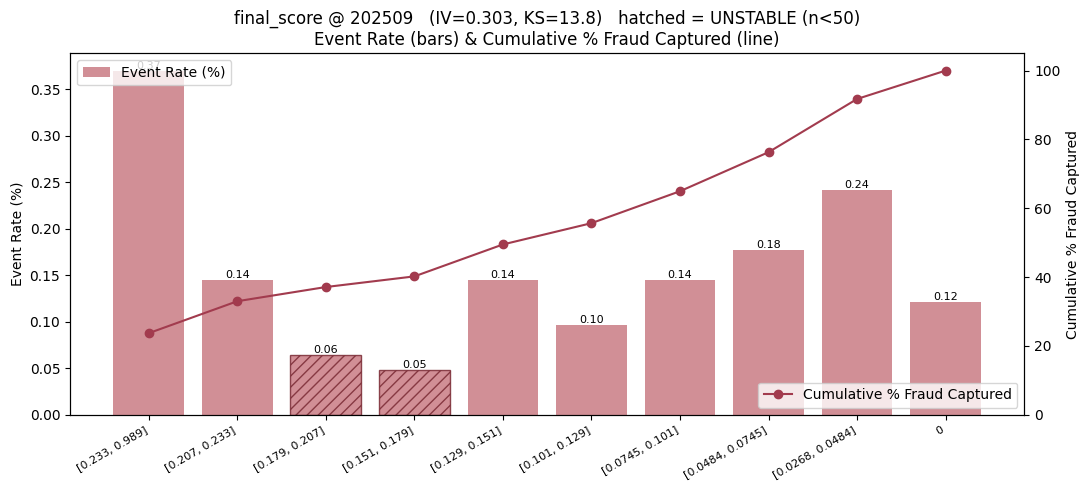

,bin,# frauds,# customers,event_rate_%,event_rate_LCB_%,cum_%_captured,stable
0,"[0.233, 0.989]",23,6219,0.370,0.25,23.71,True
1,"[0.207, 0.233]",9,6219,0.145,0.08,32.99,True
2,"[0.179, 0.207]",4,6219,0.064,0.03,37.11,False
3,"[0.151, 0.179]",3,6219,0.048,0.02,40.21,False
4,"[0.129, 0.151]",9,6218,0.145,0.08,49.48,True
5,"[0.101, 0.129]",6,6219,0.096,0.04,55.67,True
6,"[0.0745, 0.101]",9,6219,0.145,0.08,64.95,True
7,"[0.0484, 0.0745]",11,6219,0.177,0.10,76.29,True
8,"[0.0268, 0.0484]",15,6219,0.241,0.15,91.75,True
9,0,8,6627,0.121,0.06,100.00,True


In [15]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import IPython.display as _disp
from pyspark.sql import functions as _F

CUST_TBL      = "payment_cards_dev.TP99965073_v2_final_scores"
PLOT_FEATURES = ["final_score"]
PLOT_ANCHOR   = "202509"     # Sep = most matured; change to inspect another anchor
MIN_BIN_FRAC  = 0.01         # club any bin holding < 1% of customers into its neighbour
MIN_STABLE_CNT= 50           # bin with fewer customers than this is flagged UNSTABLE
MIN_STABLE_BAD= 5            # ...or fewer frauds than this
RISKY_ON_LEFT = True         # True = riskiest bin first (decile/gains look); False = feature-value order

def _wilson_lcb(bad, cnt, z=1.96):
    bad = np.asarray(bad, float); cnt = np.asarray(cnt, float)
    p = np.where(cnt > 0, bad / cnt, 0.0); denom = 1 + z*z/np.maximum(cnt, 1)
    centre = p + z*z/(2*np.maximum(cnt, 1)); margin = z*np.sqrt((p*(1-p) + z*z/(4*np.maximum(cnt,1)))/np.maximum(cnt,1))
    return np.where(cnt > 0, np.clip((centre - margin)/denom, 0, 1), 0.0)

def _robust_bins(x, max_bins=10):
    s = pd.Series(np.asarray(x, dtype=float)); nuniq = int(s.nunique(dropna=True))
    if nuniq <= 1: return np.zeros(len(s), dtype=int)
    if nuniq <= max_bins:
        order = {v: i for i, v in enumerate(sorted(s.dropna().unique()))}
        return s.map(order).fillna(0).astype(int).values
    z = (s == 0); out = np.zeros(len(s), dtype=int)
    if z.mean() >= 0.02 and int((~z).sum()) >= max_bins:
        pos = ~z
        qr = pd.qcut(s[pos].rank(method="first"), q=min(max_bins - 1, int((~z).sum())), labels=False, duplicates="drop")
        out[pos.values] = 1 + qr.astype(int).values; return out
    return pd.qcut(s.rank(method="first"), q=max_bins, labels=False, duplicates="drop").astype(int).values

def _club_sparse(d, n, min_frac):
    d = d.sort_index().copy()
    while len(d) > 2:
        share = d["cnt"] / n
        if share.min() >= min_frac: break
        j = int(share.values.argmin()); k = j + 1 if j == 0 else j - 1
        lo, hi = min(j, k), max(j, k)
        d.loc[d.index[lo], ["cnt", "bad"]] += d.loc[d.index[hi], ["cnt", "bad"]].values
        d.loc[d.index[lo], "hi"] = max(d.loc[d.index[lo], "hi"], d.loc[d.index[hi], "hi"])
        d.loc[d.index[lo], "lo"] = min(d.loc[d.index[lo], "lo"], d.loc[d.index[hi], "lo"])
        d = d.drop(d.index[hi]).reset_index(drop=True)
    return d

def _woe_iv(cnt, bad):
    good = cnt - bad; tb, tg = bad.sum(), good.sum()
    pb = (bad / tb).clip(lower=1e-6); pg = (good / tg).clip(lower=1e-6)
    return float(((pg - pb) * np.log(pg / pb)).sum())

_pdf = spark.table(CUST_TBL).where(_F.col("anchor_month") == PLOT_ANCHOR).select("target_fraud", *PLOT_FEATURES).toPandas()
_y = _pdf["target_fraud"].astype(int).values; _tot_bad = int(_y.sum()); _tot_good = len(_y) - _tot_bad
print("plotting anchor %s | customers=%d | frauds=%d" % (PLOT_ANCHOR, len(_pdf), _tot_bad))

def plot_sloping(feature):
    x = _pdf[feature].astype(float).values
    d = (pd.DataFrame({"b": _robust_bins(x), "x": x, "y": _y}).groupby("b")
         .agg(cnt=("y", "size"), bad=("y", "sum"), lo=("x", "min"), hi=("x", "max")).sort_index())
    d = _club_sparse(d, len(_pdf), MIN_BIN_FRAC)
    d = (d.iloc[::-1] if RISKY_ON_LEFT else d).reset_index(drop=True)
    d["event_rate_pct"] = 100.0 * d["bad"] / d["cnt"]
    cum_bad = d["bad"].cumsum(); cum_good = (d["cnt"] - d["bad"]).cumsum()
    d["pct_captured"] = 100.0 * cum_bad / max(_tot_bad, 1)
    ks = float((100.0 * cum_bad / max(_tot_bad, 1) - 100.0 * cum_good / max(_tot_good, 1)).abs().max())
    iv = _woe_iv(d["cnt"], d["bad"])
    d["er_lcb_pct"] = 100.0 * _wilson_lcb(d["bad"].values, d["cnt"].values)
    d["stable"] = (d["cnt"] >= MIN_STABLE_CNT) & (d["bad"] >= MIN_STABLE_BAD)
    labels = [("%.3g" % lo) if lo == hi else ("[%.3g, %.3g]" % (lo, hi)) for lo, hi in zip(d["lo"], d["hi"])]
    xs = range(len(d))
    fig, ax1 = plt.subplots(figsize=(11, 5))
    ax1.bar(xs, d["event_rate_pct"], color="#c97b84", alpha=0.85, label="Event Rate (%)")
    for i, v in enumerate(d["event_rate_pct"]): ax1.text(i, v, "%.2f" % v, ha="center", va="bottom", fontsize=8)
    ax1.set_ylabel("Event Rate (%)"); ax1.set_xticks(list(xs)); ax1.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
    for i, st in enumerate(d["stable"].values):
        if not st: ax1.patches[i].set_hatch("///"); ax1.patches[i].set_edgecolor("#7a2a34")
    ax2 = ax1.twinx()
    ax2.plot(xs, d["pct_captured"], color="#a23b4e", marker="o", label="Cumulative % Fraud Captured")
    ax2.set_ylabel("Cumulative % Fraud Captured"); ax2.set_ylim(0, 105)
    ax1.set_title("%s @ %s   (IV=%.3f, KS=%.1f)   hatched = UNSTABLE (n<%d)\nEvent Rate (bars) & Cumulative %% Fraud Captured (line)"
                  % (feature, PLOT_ANCHOR, iv, ks, MIN_STABLE_CNT), fontsize=12)
    ax1.legend(loc="upper left"); ax2.legend(loc="lower right"); fig.tight_layout(); plt.show()
    _disp.display(pd.DataFrame({"bin": labels, "# frauds": d["bad"].astype(int).values,
                                "# customers": d["cnt"].astype(int).values,
                                "event_rate_%": d["event_rate_pct"].round(3).values,
                                "event_rate_LCB_%": d["er_lcb_pct"].round(2).values,
                                "cum_%_captured": d["pct_captured"].round(2).values,
                                "stable": d["stable"].values}))

for _f in PLOT_FEATURES:
    try: plot_sloping(_f)
    except Exception as _e: print("  %s: skipped (%s)" % (_f, _e))


## FINAL. Feature audit — correlation / redundancy + fair per-feature strength (all features)
Answers "are many features correlated because they bucket the same?" (Spearman + nonzero-overlap Jaccard)
and "which features are genuinely strong?" (zeros %, Spearman-with-target, IV) — on ALL features at once.


In [16]:
FEAT_TBL     = "payment_cards_dev.TP99965073_v2_final_features"
AUDIT_ANCHOR = "202509"
HI_CORR      = 0.70
_IDC         = {"id", "anchor_month", "target_fraud", "is_candidate", "is_known_bad", "cust"}

_pa = spark.table(FEAT_TBL).where(_F.col("anchor_month") == AUDIT_ANCHOR).toPandas()
_fc = [c for c in _pa.columns if c not in _IDC and pd.api.types.is_numeric_dtype(_pa[c])]
_fc = [c for c in _fc if _pa[c].nunique(dropna=True) > 1]
_yv = _pa["target_fraud"].astype(int).values if "target_fraud" in _pa else None
_XA = _pa[_fc].astype(float).fillna(0.0)
print("audit anchor %s | customers=%d | features=%d | frauds=%d" %
      (AUDIT_ANCHOR, len(_pa), len(_fc), int(_yv.sum()) if _yv is not None else -1))

_spm = _XA.corr(method="spearman")
print("\n--- Spearman correlation ---\n", _spm.round(2).to_string())

def _jacc(a, b):
    a = a.values > 0; b = b.values > 0; u = (a | b).sum()
    return float((a & b).sum() / u) if u else 0.0

print("\n--- REDUNDANT pairs (|Spearman| > %.2f): keep only ONE ---" % HI_CORR)
_found = False
for _i in range(len(_fc)):
    for _j in range(_i + 1, len(_fc)):
        _r = _spm.iloc[_i, _j]
        if pd.notna(_r) and abs(_r) > HI_CORR:
            _found = True
            print("  %-22s ~ %-22s  Spearman=%+.2f  nonzero-overlap=%.2f"
                  % (_fc[_i], _fc[_j], _r, _jacc(_XA[_fc[_i]], _XA[_fc[_j]])))
if not _found: print("  none — features largely independent.")

def _iv10(x, yv):
    s = pd.Series(x)
    if s.nunique() <= 1: return 0.0
    try: b = pd.qcut(s.rank(method="first"), 10, labels=False, duplicates="drop")
    except Exception: b = pd.Series(np.zeros(len(s)))
    g = pd.DataFrame({"b": b, "y": yv}).groupby("b").agg(cnt=("y", "size"), bad=("y", "sum"))
    good = g["cnt"] - g["bad"]
    pb = (g["bad"] / max(g["bad"].sum(), 1)).clip(1e-6); pg = (good / max(good.sum(), 1)).clip(1e-6)
    return float(((pg - pb) * np.log(pg / pb)).sum())

_rows = []
for _c in _fc:
    _x = _XA[_c].values
    _sc = float(pd.Series(_x).corr(pd.Series(_yv), method="spearman")) if _yv is not None else np.nan
    _rows.append((_c, round(100.0*(_x==0).mean(),1), round(_sc,3) if _sc==_sc else None, round(_iv10(_x,_yv),3)))
_aud = pd.DataFrame(_rows, columns=["feature","zeros_%","spearman_vs_target","IV"]).sort_values("IV", ascending=False)
print("\n--- FAIR per-feature strength (sorted by IV) ---\n", _aud.to_string(index=False))


audit anchor 202509 | customers=62597 | features=20 | frauds=97

--- Spearman correlation ---
                        in_deg  out_deg  in_w  out_w  min_hops_to_bad  closeness_to_bad   ppr  n_shared_mule  shares_mule  comm_bad_rate  n_shared_mule_motif  max_shared_mule_fanin  ring_co_feeders  n_shared_atm  on_3cycle  n_3cycle_as_a  fraudar_score  in_dense_block  block_density  passthrough_ratio
in_deg                   1.00     0.52  0.99   0.52            -0.06              0.06  0.49           0.05         0.05           0.01                 0.05                   0.05             0.05          0.04       0.02           0.02           0.05            0.01           0.01               0.94
out_deg                  0.52     1.00  0.52   0.99            -0.03              0.03  0.83           0.07         0.07          -0.00                 0.07                   0.07             0.07          0.04       0.00           0.00           0.07            0.00           0.00               0.48